<a href="https://colab.research.google.com/github/TitiOjutiku/A02-QNS25001-KMD24003/blob/hyperparameter-tuning/California_housing_improved_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load California Housing dataset
housing = fetch_california_housing(as_frame=True)

# Features + target as a single DataFrame
df = housing.frame

# Quick check
print(df.head())
print(df.shape)

# you can save the boxplot...

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
(20640, 9)


In [3]:
from sklearn.model_selection import train_test_split

# Split data into features (X) and target (y)
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (16512, 8)
X_test shape: (4128, 8)
y_train shape: (16512,)
y_test shape: (4128,)


In [4]:
from sklearn.neural_network import MLPRegressor

# Create the MLP regression model
mlp_model = MLPRegressor(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=1000,
    early_stopping=True,
    random_state=42
)

# Train the model
mlp_model.fit(X_train, y_train)

print("MLP Regression model trained successfully.")

MLP Regression model trained successfully.


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the training data
y_train_pred = mlp_model.predict(X_train)

print("Training predictions generated successfully.")

Training predictions generated successfully.


### Visualizing Training Predictions

These plots help to understand how well the model is performing on the training data:

1.  **Actual vs. Predicted Plot**: This scatter plot compares the actual `MedHouseVal` (y_train) with the predicted `MedHouseVal` (y_train_pred). A perfect model would show all points falling on a 45-degree line.

2.  **Residual Plot**: This plot shows the difference between the actual and predicted values (residuals) against the predicted values. Ideally, residuals should be randomly scattered around zero, indicating that the model captures the underlying patterns well and there are no systematic errors.

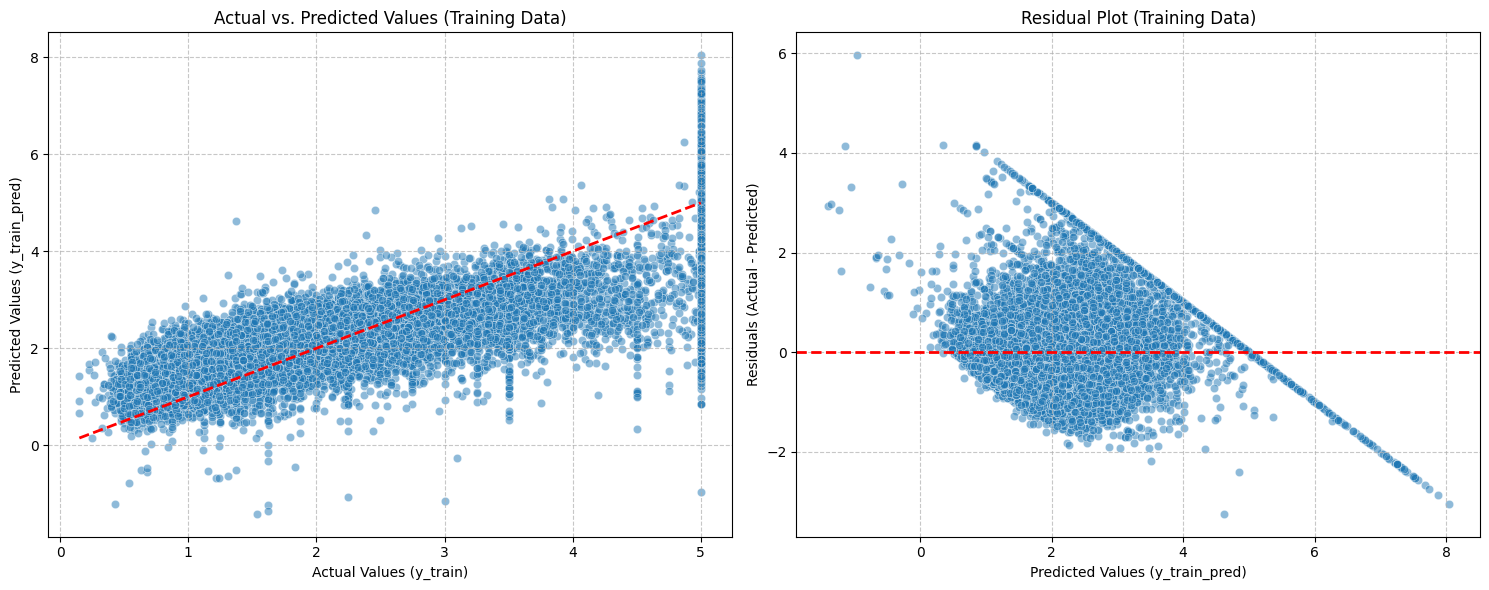

In [6]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Actual vs. Predicted values
sns.scatterplot(x=y_train, y=y_train_pred, ax=axes[0], alpha=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2) # Ideal line
axes[0].set_xlabel('Actual Values (y_train)')
axes[0].set_ylabel('Predicted Values (y_train_pred)')
axes[0].set_title('Actual vs. Predicted Values (Training Data)')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Residuals vs. Predicted values
residuals = y_train - y_train_pred
sns.scatterplot(x=y_train_pred, y=residuals, ax=axes[1], alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2) # Zero residual line
axes[1].set_xlabel('Predicted Values (y_train_pred)')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title('Residual Plot (Training Data)')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [7]:
# Save the figure to a file
plot_filename = 'training_predictions_plots.png'
fig.savefig(plot_filename)

print(f"Plots saved to {plot_filename}")

Plots saved to training_predictions_plots.png


In [8]:
# Model Evaluation Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Generate predictions on the test data
y_test_pred = mlp_model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

# Display results
print("Model Evaluation - Test Data")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

Model Evaluation - Test Data
MSE:  0.6102
RMSE: 0.7812
MAE:  0.5857
R²:   0.5343


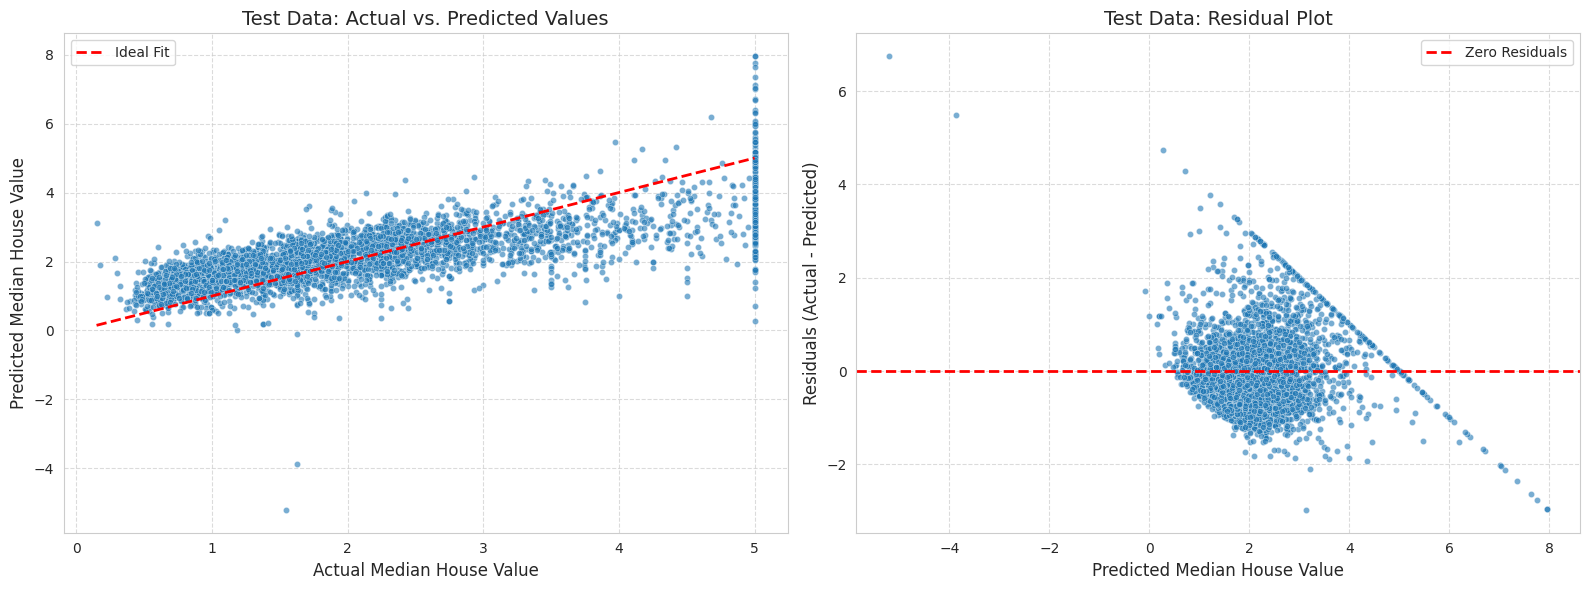

Improved test evaluation plots saved as test_evaluation_plots_improved.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for better aesthetics

# Calculate residuals
test_residuals = y_test - y_test_pred

# Set a clean style for plots
sns.set_style("whitegrid")

# Create evaluation plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs Predicted
sns.scatterplot(x=y_test, y=y_test_pred, ax=axes[0], alpha=0.6, s=20) # Added s for point size
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', lw=2, label='Ideal Fit'
)
axes[0].set_xlabel("Actual Median House Value", fontsize=12)
axes[0].set_ylabel("Predicted Median House Value", fontsize=12)
axes[0].set_title("Test Data: Actual vs. Predicted Values", fontsize=14)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Residual Plot
sns.scatterplot(x=y_test_pred, y=test_residuals, ax=axes[1], alpha=0.6, s=20)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2, label='Zero Residuals')
axes[1].set_xlabel("Predicted Median House Value", fontsize=12)
axes[1].set_ylabel("Residuals (Actual - Predicted)", fontsize=12)
axes[1].set_title("Test Data: Residual Plot", fontsize=14)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

# Save plot with higher resolution
plt.savefig("test_evaluation_plots_improved.png", dpi=300, bbox_inches="tight")

plt.show()

print("Improved test evaluation plots saved as test_evaluation_plots_improved.png")

### Visualizing Improved Training Predictions

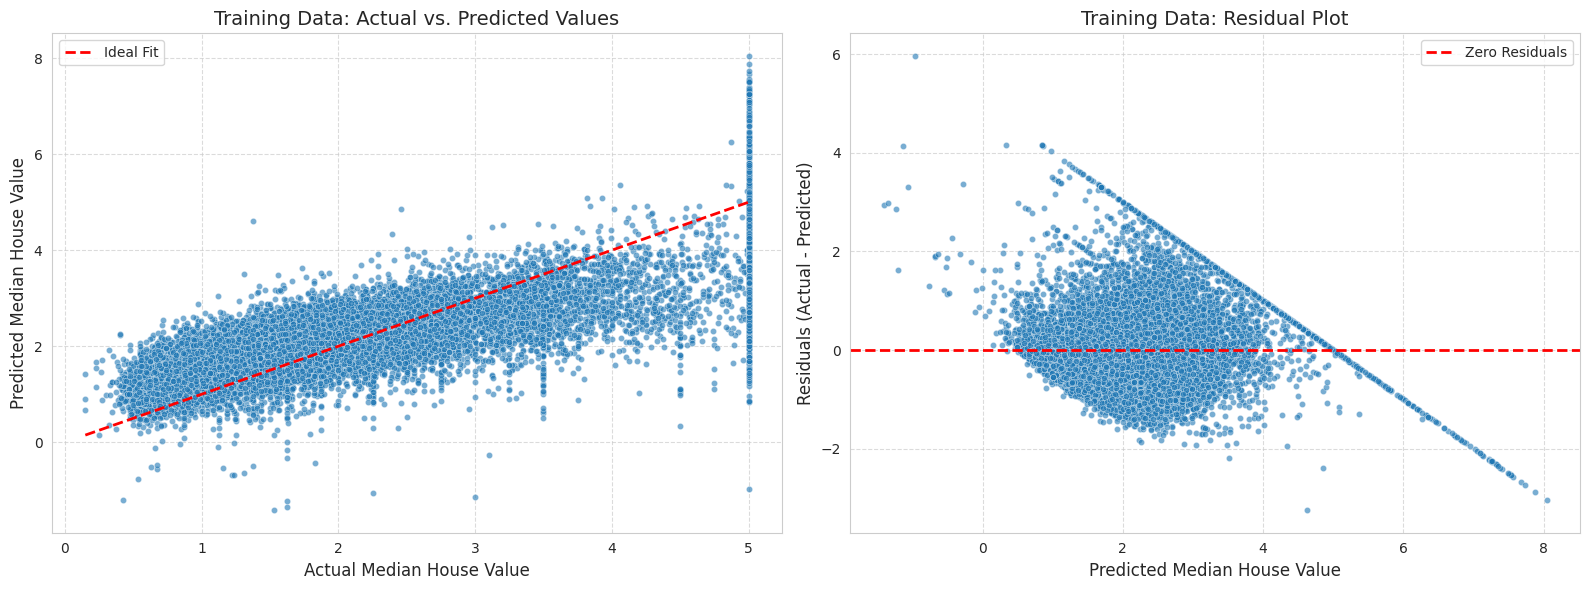

Improved training evaluation plots saved as training_evaluation_plots_improved.png


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals for training data
train_residuals = y_train - y_train_pred

# Set a clean style for plots (consistent with test plots)
sns.set_style("whitegrid")

# Create a figure with two subplots
fig_train, axes_train = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs. Predicted values (Training Data)
sns.scatterplot(x=y_train, y=y_train_pred, ax=axes_train[0], alpha=0.6, s=20) # Added s for point size
axes_train[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Ideal Fit')
axes_train[0].set_xlabel('Actual Median House Value', fontsize=12)
axes_train[0].set_ylabel('Predicted Median House Value', fontsize=12)
axes_train[0].set_title('Training Data: Actual vs. Predicted Values', fontsize=14)
axes_train[0].legend()
axes_train[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Residuals vs. Predicted values (Training Data)
sns.scatterplot(x=y_train_pred, y=train_residuals, ax=axes_train[1], alpha=0.6, s=20)
axes_train[1].axhline(y=0, color='r', linestyle='--', lw=2, label='Zero Residuals')
axes_train[1].set_xlabel('Predicted Median House Value', fontsize=12)
axes_train[1].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
axes_train[1].set_title('Training Data: Residual Plot', fontsize=14)
axes_train[1].legend()
axes_train[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

# Save plot with higher resolution
plt.savefig("training_evaluation_plots_improved.png", dpi=300, bbox_inches="tight")

plt.show()

print("Improved training evaluation plots saved as training_evaluation_plots_improved.png")

The plots were significantly improved through enhanced aesthetics with seaborn, larger figure and point sizes for readability, and clearer titles, labels, and legends for better context. Emphasized reference lines and improved grid visibility further aid interpretation, with all plots now saved in high resolution.



This section compares the model's performance on the training and test datasets to evaluate how well the model generalisez to unseen data.

In [10]:
# Model Performance Comparison: Training vs Test Data

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Training metrics
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Test metrics
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Create comparison table
performance_comparison = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE", "R²"],
    "Training": [train_mse, train_rmse, train_mae, train_r2],
    "Test": [test_mse, test_rmse, test_mae, test_r2]
})

print("Model Performance Comparison")
display(performance_comparison.round(4))

Model Performance Comparison


,Metric,Training,Test
0,MSE,0.5748,0.6102
1,RMSE,0.7581,0.7812
2,MAE,0.5729,0.5857
3,R²,0.5700,0.5343


Interpretation: The model performs similarly on the training and test datasets. The test RMSE and MAE are slightly higher than the training values, while the test R² is slightly lower. This indicates a modest decrease in performance on unseen data, but there is no large gap between training and test performance.

## MLP hyperparameter tuning and Performance Comparison.
Hyperparameter tuning is performed using cross-validation to identify improved settings for the MLP regression model. the tuned model is then evaluated on the test set and compared with the baseline model using RMSE and R²


In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Define hyperparameters to test
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001],
    'learning_rate_init': [0.001, 0.01]
}

# Create MLP model for tuning
mlp_tuning = MLPRegressor(
    solver='adam',
    max_iter=1000,
    early_stopping=True,
    random_state=42
)

# Perform 3-fold cross-validation
grid_search = GridSearchCV(
    mlp_tuning,
    param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Tune using training data only
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:")
print(grid_search.best_params_)

# Select best model
tuned_mlp = grid_search.best_estimator_

# Make predictions on test data
tuned_pred = tuned_mlp.predict(X_test)

# Calculate tuned model performance
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))
tuned_r2 = r2_score(y_test, tuned_pred)

print("\nTuned MLP Test Performance")
print(f"RMSE: {tuned_rmse:.4f}")
print(f"R²: {tuned_r2:.4f}")

Best Hyperparameters:
{'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001}

Tuned MLP Test Performance
RMSE: 0.7041
R²: 0.6216


Baseline vs. Tuned MLP Performance


,Model,RMSE,R²
0,Baseline MLP,0.7812,0.5343
1,Tuned MLP,0.7041,0.6216


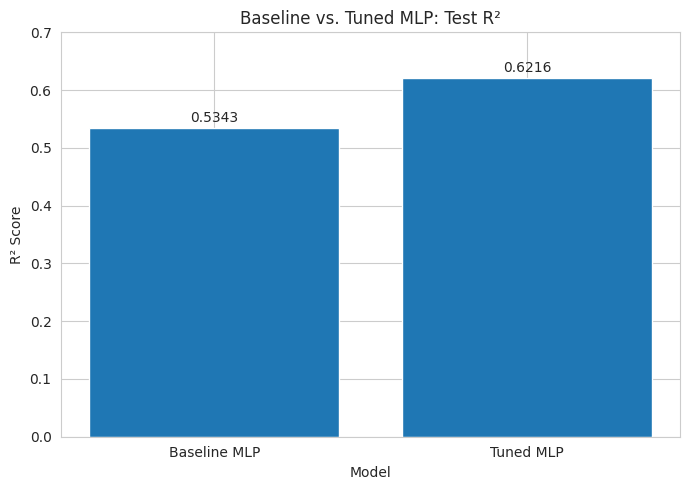

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Baseline and tuned model results
comparison = pd.DataFrame({
    "Model": ["Baseline MLP", "Tuned MLP"],
    "RMSE": [test_rmse, tuned_rmse],
    "R²": [test_r2, tuned_r2]
})

print("Baseline vs. Tuned MLP Performance")
display(comparison.round(4))

# Plot R² comparison
plt.figure(figsize=(7, 5))
bars = plt.bar(comparison["Model"], comparison["R²"])

plt.title("Baseline vs. Tuned MLP: Test R²")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.ylim(0, 0.7)

# Add values above bars
for bar, value in zip(bars, comparison["R²"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.01,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()

# Save figure as PNG
plt.savefig(
    "baseline_vs_tuned_mlp.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()